# Evaporator Optimization: Constraint Variation for Data Diversity

This notebook demonstrates generative optimization using **constraint variation** to create diverse training data.

**Key approach:**
1. **Vary constraint bounds** (X2_min, P100_max) to get different optimal solutions
2. **Condition on h(x) = 0** (constraint residuals) to generate feasible points
3. **Compare GMM vs Flow Matching** performance

**Why constraint variation?**
- Multistart optimization often converges to the same global optimum (no diversity)
- Different constraint configurations → different optimal solutions → diverse training data
- Each training point satisfies h(x) ≈ 0 with different X2 and P100 values

**Training data approach (matching `evaporator_gmm_fm_comparison.ipynb`):**
1. Solve SLSQP for grid of (X2_min, P100_max) configurations
2. Build GMM/FM on joint distribution [x, h(x)]
3. Condition on h(x) = 0 to find feasible points

## System Information

In [1]:
import sys
import platform
import time
import psutil
import os

print("System Information")
print("=" * 70)
print(f"Python version: {sys.version}")
print(f"Platform: {platform.platform()}")
print(f"Processor: {platform.processor()}")
print(f"CPU count: {psutil.cpu_count(logical=False)} physical, {psutil.cpu_count(logical=True)} logical")
print(f"Total memory: {psutil.virtual_memory().total / (1024**3):.2f} GB")
print("=" * 70)

# Key package versions
print("\nKey Library Versions:")
print("-" * 70)
packages = [
    ('numpy', 'np'),
    ('scipy', 'scipy'),
    ('matplotlib', 'matplotlib'),
    ('sklearn', 'sklearn'),
    ('torch', 'torch'),
    ('gmr', 'gmr'),
]

for pkg_name, import_name in packages:
    try:
        mod = __import__(pkg_name)
        version = getattr(mod, '__version__', 'unknown')
        print(f"{pkg_name:<20} {version}")
    except ImportError:
        print(f"{pkg_name:<20} NOT INSTALLED")

print("-" * 70)

# Initialize timing and memory tracking
_start_time = time.time()
_process = psutil.Process(os.getpid())
_start_memory_mb = _process.memory_info().rss / (1024 * 1024)

print(f"\nNotebook execution started: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_start_time))}")
print(f"Initial memory usage: {_start_memory_mb:.2f} MB")
print("=" * 70)

System Information
Python version: 3.13.5 (main, Jun 11 2025, 15:36:57) [Clang 17.0.0 (clang-1700.0.13.3)]
Platform: macOS-26.5.2-arm64-arm-64bit-Mach-O
Processor: arm
CPU count: 14 physical, 14 logical
Total memory: 64.00 GB

Key Library Versions:
----------------------------------------------------------------------
numpy                2.3.5
scipy                1.16.3


matplotlib           3.10.8


sklearn              1.8.0


torch                2.9.1
gmr                  2.0.2
----------------------------------------------------------------------

Notebook execution started: 2026-08-23 14:02:18
Initial memory usage: 300.48 MB


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings

import torch
from scipy.optimize import minimize
from scipy.stats.qmc import LatinHypercube, scale as qmc_scale
from tqdm.auto import tqdm

# Import reusable utilities
from generative_optimization import (
    generate_samples,
    best_gmm,
    cluster_stats,
    ConditionalFlowMatching
)

# Figure settings
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['figure.dpi'] = 150
mpl.rcParams['font.size'] = 10

warnings.filterwarnings('ignore')
np.random.seed(42)
torch.manual_seed(42)

print("Setup complete")

Setup complete


## Problem Definition

The forced-circulation evaporator optimization problem is from Newell & Lee (1989).

**Reference:** R.B. Newell and P.L. Lee, *Applied Process Control: A Case Study*, Prentice Hall, 1989.

**16 Decision Variables:**
- $F_1, F_2, F_3, F_4, F_5$: Flow rates (kg/min)
- $X_2$: Product composition (%)
- $T_2, T_3$: Temperatures (°C)
- $P_2$: Separator pressure (kPa)
- $F_{100}$: Steam flow rate (kg/min)
- $T_{100}$: Steam temperature (°C)
- $P_{100}$: Steam pressure (kPa)
- $Q_{100}$: Heat duty (kW)
- $F_{200}$: Cooling water flow (kg/min)
- $T_{201}$: Cooling water outlet temperature (°C)
- $Q_{200}$: Condenser duty (kW)

**Objective:** Minimize cost
$$\text{Cost} = 600F_{100} + 0.6F_{200} + 1.009(F_2 + F_3) + 0.2F_1 - 4800F_2$$

**12 Equality Constraints:** Mass and energy balances (steady state)

**Inequality Constraints (varied for training data diversity):**
- $X_2 \geq X_2^{\min}$ (varied: 33% to 38%)
- $P_{100} \leq P_{100}^{\max}$ (varied: 260 to 400 kPa)
- $40 \leq P_2 \leq 80$ kPa (fixed)

In [3]:
# Variable names and indices
# 0:F1, 1:F2, 2:F3, 3:F4, 4:F5, 5:X2, 6:T2, 7:T3, 8:P2, 9:F100,
# 10:T100, 11:P100, 12:Q100, 13:F200, 14:T201, 15:Q200

NAMES = ['F1', 'F2', 'F3', 'F4', 'F5', 'X2', 'T2', 'T3', 'P2', 'F100',
         'T100', 'P100', 'Q100', 'F200', 'T201', 'Q200']

# Constants (disturbances / fixed)
X1 = 5.0    # %
T1 = 40.0   # °C
T200 = 25.0 # °C

# Bounds (lb/ub) - physical limits
lb = np.array([0.1, 0.1, 0.1, 0.1, 0.1, 20, 40, 40, 40, 0.1, 100, 102, 300, 0.1, 20, 200], dtype=float)
ub = np.array([20, 20, 100, 20, 20, 40, 100, 100, 80, 20, 300, 400, 500, 400, 100, 500], dtype=float)

# Literature optimum (for comparison only - NOT used for training)
x_opt_lit = np.array([
    9.469, 1.334, 24.721, 8.135, 8.135, 35.500, 88.400, 81.066, 51.412,
    9.434, 151.520, 400.000, 345.292, 217.738, 45.550, 313.210
], dtype=float)

def objective(x):
    """Cost function to minimize (economic objective)."""
    F1, F2, F3 = x[0], x[1], x[2]
    F100, F200 = x[9], x[13]
    return 600*F100 + 0.6*F200 + 1.009*(F2 + F3) + 0.2*F1 - 4800*F2

def equalities(x):
    """12 equality constraints (mass and energy balances)."""
    F1, F2, F3, F4, F5, X2, T2, T3, P2, F100, T100, P100, Q100, F200, T201, Q200 = x
    
    eq = np.zeros(12)
    eq[0] = (F1 - F4 - F2) / 20.0                                    # dL2/dt = 0
    eq[1] = (F1*X1 - F2*X2) / 20.0                                   # dX2/dt = 0
    eq[2] = (F4 - F5) / 4.0                                          # dP2/dt = 0
    eq[3] = 0.5616*P2 + 0.3126*X2 + 48.43 - T2                       # T2 correlation
    eq[4] = 0.507*P2 + 55.0 - T3                                     # T3 correlation
    eq[5] = (Q100 - 0.07*F1*(T2 - T1)) / 38.5 - F4                   # F4 energy balance
    eq[6] = 0.1538*P100 + 90.0 - T100                                # T100 correlation
    eq[7] = 0.16*(F1 + F3)*(T100 - T2) - Q100                        # Heater duty
    eq[8] = Q100 / 36.6 - F100                                       # Steam flow
    ratio = (T3 - T200) / (0.14*F200 + 6.84)
    eq[9] = 0.9576*F200*ratio - Q200                                 # Condenser duty
    eq[10] = T200 + 13.68*ratio - T201                               # Cooling water outlet temp
    eq[11] = Q200 / 38.5 - F5                                        # Condensate flow
    return eq

def max_constraint_violation(x):
    """Compute maximum equality constraint violation."""
    return np.max(np.abs(equalities(x)))

print("Problem functions defined")
print(f"Literature solution cost: {objective(x_opt_lit):.4f}")
print(f"Literature solution max constraint violation: {max_constraint_violation(x_opt_lit):.2e}")

Problem functions defined
Literature solution cost: -583.9739
Literature solution max constraint violation: 1.48e-03


## Target Problem

For final inference, we want to solve:
```
minimize   J(x)
subject to h(x) = 0        (12 equality constraints)
           X2 >= 35.5      (target lower bound)
           40 <= P2 <= 80  (fixed bounds)
           P100 <= 400     (target upper bound)
```

**Training data generation:**
- We vary X2_min ∈ [33%, 38%] and P100_max ∈ [260, 400] kPa
- Solve SLSQP for each (X2_min, P100_max) configuration
- This gives diverse feasible solutions (different optimal X2 and P100 values)

**Generative model conditioning:**
- Train on joint distribution [x, h(x)]
- Condition on h(x) = 0 at inference time
- This selects feasible points from the learned distribution

In [4]:
# SLSQP solver with configurable constraint bounds
def solve_slsqp(X2_min, P100_max, x0):
    """
    Solve the evaporator optimization with given constraint bounds.
    
    Args:
        X2_min: Lower bound on X2 (product composition %)
        P100_max: Upper bound on P100 (steam pressure kPa)
        x0: Initial guess
    
    Returns:
        scipy.optimize.OptimizeResult
    """
    def inequalities(x):
        X2, P2, P100 = x[5], x[8], x[11]
        return np.array([
            X2 - X2_min,       # X2 >= X2_min
            P2 - 40.0,         # P2 >= 40
            80.0 - P2,         # P2 <= 80
            P100_max - P100    # P100 <= P100_max
        ])
    
    constraints = [
        {'type': 'eq', 'fun': equalities},
        {'type': 'ineq', 'fun': inequalities}
    ]
    
    res = minimize(
        objective, x0, 
        bounds=list(zip(lb, ub)), 
        constraints=constraints, 
        method='SLSQP',
        options={'maxiter': 500, 'ftol': 1e-8}
    )
    return res

# Test the SLSQP solver with target constraints
x0 = np.array([10, 1, 25, 8, 8, 36, 85, 80, 55, 9, 150, 350, 350, 200, 50, 300], dtype=float)
res_test = solve_slsqp(X2_min=35.5, P100_max=400.0, x0=x0)

print("SLSQP Solver Test (target constraints: X2 >= 35.5, P100 <= 400)")
print(f"  Success: {res_test.success}")
print(f"  Objective: {res_test.fun:.4f}")
print(f"  Max constraint violation: {max_constraint_violation(res_test.x):.2e}")
print(f"  X2 = {res_test.x[5]:.4f}, P100 = {res_test.x[11]:.4f}")

SLSQP Solver Test (target constraints: X2 >= 35.5, P100 <= 400)
  Success: True
  Objective: -582.2331
  Max constraint violation: 3.08e-09
  X2 = 35.5000, P100 = 400.0000


## Reference Solution with Scipy

We solve the target problem (X2 >= 35.5, P100 <= 400) for reference.

In [5]:
# Target problem constraints
TARGET_X2_MIN = 35.5
TARGET_P100_MAX = 400.0

# Solve target problem with scipy
x0 = np.array([10, 1, 25, 8, 8, 36, 85, 80, 55, 9, 150, 350, 350, 200, 50, 300], dtype=float)
res = solve_slsqp(TARGET_X2_MIN, TARGET_P100_MAX, x0)

print("Scipy Solution (SLSQP) - Target Problem")
print("=" * 70)
print(f"Success: {res.success} | Objective (Cost): {res.fun:.4f}")
print(f"Max equality constraint violation: {max_constraint_violation(res.x):.2e}")
print(f"\nKey variables:")
print(f"  X2 = {res.x[5]:.4f} (target: >= {TARGET_X2_MIN})")
print(f"  P100 = {res.x[11]:.4f} (target: <= {TARGET_P100_MAX})")

# Store scipy solution for comparison
scipy_solution = res.x.copy()
scipy_cost = res.fun

Scipy Solution (SLSQP) - Target Problem
Success: True | Objective (Cost): -582.2331
Max equality constraint violation: 3.08e-09

Key variables:
  X2 = 35.5000 (target: >= 35.5)
  P100 = 400.0000 (target: <= 400.0)


---

# Data Generation: Constraint Variation

**Problem:** Multistart optimization often converges to the same global optimum, giving no diversity in training data.

**Solution:** Vary the constraint bounds to get different optimal solutions.

**Approach:**
1. Create a grid of (X2_min, P100_max) configurations
2. Solve SLSQP for each configuration
3. Each solution satisfies h(x) ≈ 0 but with different X2 and P100 values
4. Use warm starting for faster convergence

**Configuration:**
- X2_min ∈ [33%, 38%] (20 values)
- P100_max ∈ [260, 400] kPa (20 values)
- Total: 400 constraint configurations → ~400 diverse feasible solutions

In [6]:
# Configuration for data generation
N_GRID = 30  # Grid size for each constraint dimension (increased for more FM training data)

# Constraint variation ranges
X2_MIN_RANGE = (33.0, 38.0)
P100_MAX_RANGE = (260.0, 400.0)

print("Data Generation Configuration:")
print("=" * 70)
print(f"Grid: {N_GRID} x {N_GRID} = {N_GRID**2} constraint configurations")
print(f"X2_min ∈ [{X2_MIN_RANGE[0]}, {X2_MIN_RANGE[1]}] %")
print(f"P100_max ∈ [{P100_MAX_RANGE[0]}, {P100_MAX_RANGE[1]}] kPa")
print(f"\nTarget problem: X2 >= {TARGET_X2_MIN}, P100 <= {TARGET_P100_MAX}")

Data Generation Configuration:
Grid: 30 x 30 = 900 constraint configurations
X2_min ∈ [33.0, 38.0] %
P100_max ∈ [260.0, 400.0] kPa

Target problem: X2 >= 35.5, P100 <= 400.0


In [7]:
# Generate training data by varying constraint bounds
print("=" * 70)
print("Generating training data via constraint variation")
print("=" * 70)

X2_min_values = np.linspace(X2_MIN_RANGE[0], X2_MIN_RANGE[1], N_GRID)
P100_max_values = np.linspace(P100_MAX_RANGE[0], P100_MAX_RANGE[1], N_GRID)

solutions = []
configs = []  # Store (X2_min, P100_max) for each solution

# Starting point
x0 = np.array([10, 1, 25, 8, 8, 36, 85, 80, 55, 9, 150, 350, 350, 200, 50, 300], dtype=float)

print(f"\nSolving SLSQP for {N_GRID}x{N_GRID} = {N_GRID**2} constraint configurations...")

for X2_min in tqdm(X2_min_values, desc="X2_min variations"):
    for P100_max in P100_max_values:
        try:
            res = solve_slsqp(X2_min, P100_max, x0)
            if res.success and max_constraint_violation(res.x) < 0.01:
                solutions.append(res.x)
                configs.append((X2_min, P100_max))
                x0 = res.x  # Warm start for next iteration
        except:
            pass

X_train = np.array(solutions)
configs = np.array(configs)

print(f"\nGenerated {len(X_train)} feasible solutions")
print(f"Success rate: {100*len(X_train)/(N_GRID**2):.1f}%")

Generating training data via constraint variation

Solving SLSQP for 30x30 = 900 constraint configurations...


X2_min variations:   0%|          | 0/30 [00:00<?, ?it/s]


Generated 719 feasible solutions
Success rate: 79.9%


In [8]:
# Compute constraint residuals for training
eq_train = np.array([equalities(x) for x in X_train])
obj_train = np.array([objective(x) for x in X_train])
viol_train = np.array([max_constraint_violation(x) for x in X_train])

# Extract X2 and P100 values to check diversity
X2_train = X_train[:, 5]
P100_train = X_train[:, 11]

print("Training Data Statistics:")
print("=" * 70)
print(f"Total samples: {len(X_train)}")
print(f"\nConstraint violation:")
print(f"  Max: {viol_train.max():.2e}")
print(f"  Mean: {viol_train.mean():.2e}")
print(f"\nObjective range (shows diversity!):")
print(f"  Min: {obj_train.min():.2f}")
print(f"  Max: {obj_train.max():.2f}")
print(f"  Mean: {obj_train.mean():.2f}")
print(f"\nX2 range: [{X2_train.min():.2f}, {X2_train.max():.2f}] (target: {TARGET_X2_MIN})")
print(f"P100 range: [{P100_train.min():.2f}, {P100_train.max():.2f}] (target: {TARGET_P100_MAX})")

print(f"\nKey insight: Diverse objectives show different optimal solutions!")
print(f"  Compare to multistart: all {len(X_train)} points had objective ≈ -582")

Training Data Statistics:
Total samples: 719

Constraint violation:
  Max: 8.86e-08
  Mean: 1.03e-08

Objective range (shows diversity!):
  Min: -1262.13
  Max: -131.21
  Mean: -590.08

X2 range: [33.00, 38.00] (target: 35.5)
P100 range: [260.00, 400.00] (target: 400.0)

Key insight: Diverse objectives show different optimal solutions!
  Compare to multistart: all 719 points had objective ≈ -582


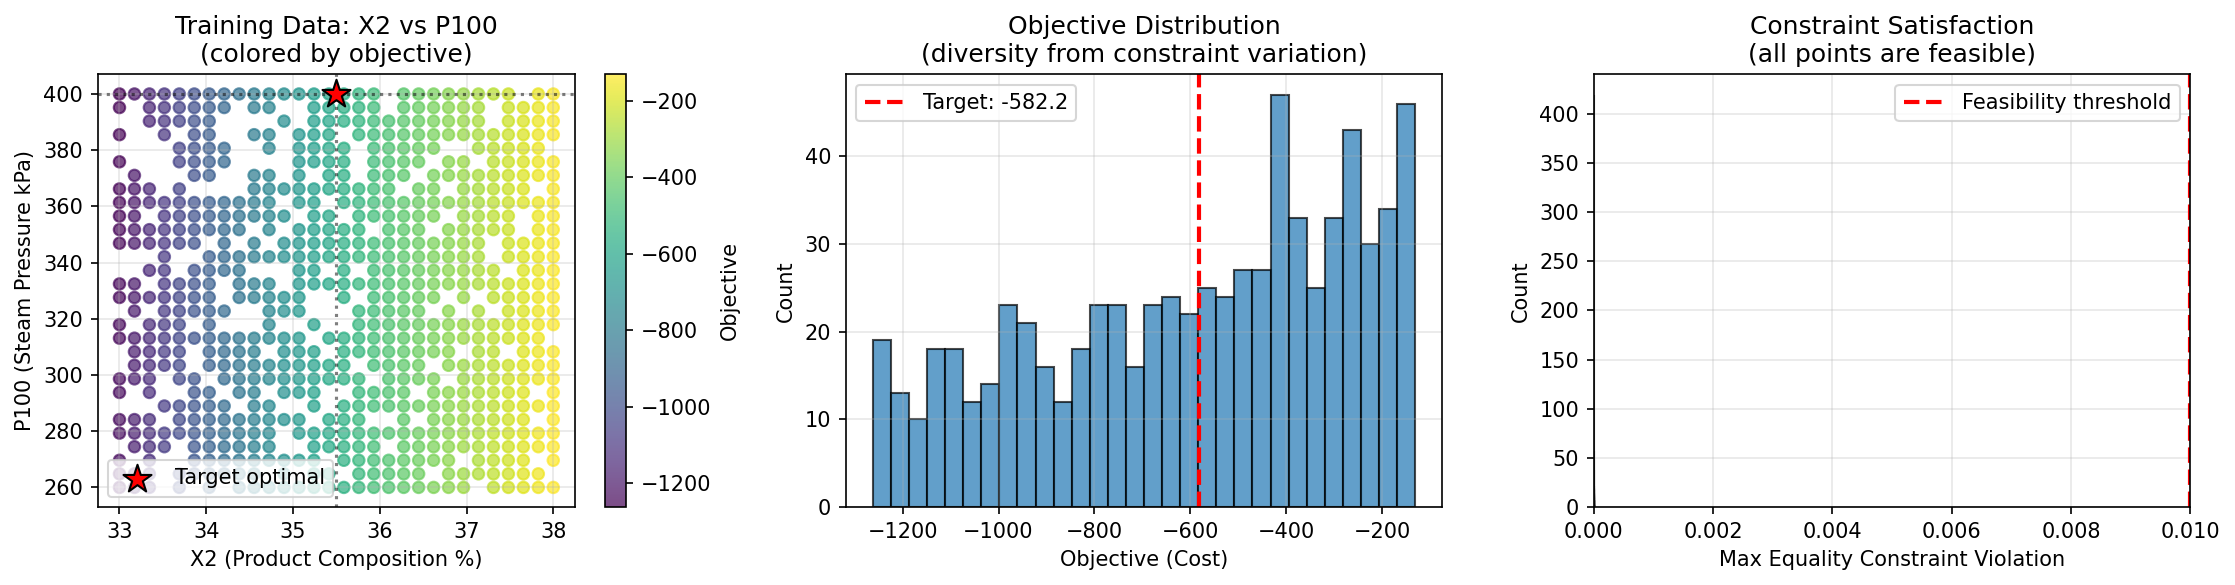


Key observation: Diverse objectives (unlike multistart with same optimum)
Objective range: [-1262.1, -131.2]


In [9]:
# Visualize training data - showing diversity from constraint variation
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. X2 vs P100 colored by objective
ax = axes[0]
sc = ax.scatter(X2_train, P100_train, c=obj_train, cmap='viridis', alpha=0.7, s=30)
ax.scatter([scipy_solution[5]], [scipy_solution[11]], c='red', s=200, 
          marker='*', label='Target optimal', zorder=10, edgecolors='black', linewidths=1)
ax.axhline(TARGET_P100_MAX, color='k', ls=':', alpha=0.5)
ax.axvline(TARGET_X2_MIN, color='k', ls=':', alpha=0.5)
ax.set_xlabel('X2 (Product Composition %)')
ax.set_ylabel('P100 (Steam Pressure kPa)')
ax.set_title('Training Data: X2 vs P100\n(colored by objective)')
plt.colorbar(sc, ax=ax, label='Objective')
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)

# 2. Objective distribution (showing diversity!)
ax = axes[1]
ax.hist(obj_train, bins=30, alpha=0.7, edgecolor='black')
ax.axvline(scipy_cost, color='red', ls='--', lw=2, label=f'Target: {scipy_cost:.1f}')
ax.set_xlabel('Objective (Cost)')
ax.set_ylabel('Count')
ax.set_title('Objective Distribution\n(diversity from constraint variation)')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Constraint residuals (should all be near zero)
ax = axes[2]
ax.hist(viol_train, bins=30, alpha=0.7, edgecolor='black')
ax.axvline(0.01, color='red', ls='--', lw=2, label='Feasibility threshold')
ax.set_xlabel('Max Equality Constraint Violation')
ax.set_ylabel('Count')
ax.set_title('Constraint Satisfaction\n(all points are feasible)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, max(0.01, viol_train.max()*1.1))

plt.tight_layout()
plt.savefig('evaporator_constraint_variation_data.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nKey observation: Diverse objectives (unlike multistart with same optimum)")
print(f"Objective range: [{obj_train.min():.1f}, {obj_train.max():.1f}]")

## Prepare Training Data for Generative Models

Training data includes:
- **x**: 16 decision variables
- **h(x)**: 12 equality constraint residuals

Total: **28 dimensions**

Conditioning will be on **h(x) = 0** (12 conditions).

In [10]:
# Training data summary
print(f"Training data summary:")
print(f"  Total samples: {len(X_train)}")
print(f"  x dimensions: {X_train.shape[1]} (decision variables)")
print(f"  h(x) dimensions: {eq_train.shape[1]} (constraint residuals)")
print(f"\nConstraint residual statistics:")
print(f"  Max |h(x)|: {np.abs(eq_train).max():.2e}")
print(f"  Mean |h(x)|: {np.abs(eq_train).mean():.2e}")
print(f"\nObjective diversity (key advantage of constraint variation):")
print(f"  Range: [{obj_train.min():.2f}, {obj_train.max():.2f}]")
print(f"  Std: {obj_train.std():.2f}")

Training data summary:
  Total samples: 719
  x dimensions: 16 (decision variables)
  h(x) dimensions: 12 (constraint residuals)

Constraint residual statistics:
  Max |h(x)|: 8.86e-08
  Mean |h(x)|: 1.17e-09

Objective diversity (key advantage of constraint variation):
  Range: [-1262.13, -131.21]
  Std: 321.30


---

# Part 1: Gaussian Mixture Model (GMM) Approach

**Constraint Bound + Residual Conditioning:**
- Build GMM on joint distribution of **(x, h(x))** (28 dimensions)
- Condition on **X2 = 35.5** (target lower bound, column 5)
- Condition on **P100 = 400** (target upper bound, column 11)  
- Condition on **h(x) = 0** (12 equality constraints, columns 16-27)
- Total: 14 conditioning values → generates remaining 14 decision variables

**Why this works:**
- Training data has diverse (X2, P100) pairs from constraint variation
- Model learns how solution changes as constraint bounds change
- At inference, we specify target constraint bounds → model generates consistent solution
- Similar to parameter estimation: condition on known values, generate unknowns

In [11]:
# Build GMM on (x, h(x))
# Columns: [x1, ..., x16, h1, ..., h12] = 28 columns

data_gmm = np.hstack([X_train, eq_train])
print(f"GMM training data shape: {data_gmm.shape}")
print(f"  - x: columns 0-15 (decision variables)")
print(f"  - h(x): columns 16-27 (constraint residuals)")

# Fit GMM
print("\nTraining GMM...")
gmm, info = best_gmm(data_gmm, max_components=50, verbose=True, patience=15)
print(f"\nBest model: {info['best_k']} components")

GMM training data shape: (719, 28)
  - x: columns 0-15 (decision variables)
  - h(x): columns 16-27 (constraint residuals)

Training GMM...
k=1: BIC=-156432.5 *


k=2: BIC=-172682.2 *


k=3: BIC=-175705.9 *
k=4: BIC=-175539.8


k=5: BIC=-174981.4


k=6: BIC=-173455.8


...

k=14: BIC=-154411.4


k=15: BIC=-151902.4


k=16: BIC=-148763.6


k=17: BIC=-146813.0


k=18: BIC=-144061.3
Early stopping at k=18

Best model: 3 components


In [12]:
# Workaround for gmr.GMM.condition() bug in version 2.0.2
from gmr import MVN

def sample_gmm_conditional(gmm, cond_indices, cond_values, n_samples=1000):
    """Sample from P(x|c) by conditioning each GMM component and mixing.
    
    Workaround for gmr.GMM.condition() bug in version 2.0.2.
    
    Args:
        gmm: Fitted GMM model
        cond_indices: Indices of columns to condition on
        cond_values: Values to condition those columns to
        n_samples: Number of samples to generate
    
    Returns:
        np.ndarray of shape (n_samples, remaining_dims)
    """
    cond_values = np.atleast_1d(cond_values)
    n_components = gmm.n_components
    
    # For each component, compute the conditional distribution and weight
    conditional_means = []
    conditional_covs = []
    weights = []
    
    for k in range(n_components):
        mvn = MVN(mean=gmm.means[k], covariance=gmm.covariances[k])
        
        # Condition this component on the target value
        cond_mvn = mvn.condition(cond_indices, cond_values)
        conditional_means.append(cond_mvn.mean)
        conditional_covs.append(cond_mvn.covariance)
        
        # Weight by prior * P(cond_value | component k)
        marginal = mvn.marginalize(cond_indices)
        likelihood = marginal.to_probability_density(cond_values.reshape(1, -1))[0]
        weights.append(gmm.priors[k] * likelihood)
    
    # Normalize weights
    weights = np.array(weights)
    weights = weights / weights.sum()
    
    # Sample from mixture
    samples = []
    component_counts = np.random.multinomial(n_samples, weights)
    
    for k in range(n_components):
        if component_counts[k] > 0:
            mean = conditional_means[k]
            cov = conditional_covs[k]
            if np.isscalar(cov):
                cov = np.array([[cov]])
            comp_samples = np.random.multivariate_normal(mean.flatten(), cov, component_counts[k])
            samples.append(comp_samples)
    
    return np.vstack(samples)

# Condition on X2 = 35.5, P100 = 400, AND h(x) = 0
# X2 is column 5, P100 is column 11, h(x) is columns 16-27
constraint_cols = [5, 11] + list(range(16, 28))  # 14 conditioning columns
target_X2 = TARGET_X2_MIN      # 35.5
target_P100 = TARGET_P100_MAX  # 400.0
cond_values = np.array([target_X2, target_P100] + [0.0]*12)

print(f"Conditioning on {len(constraint_cols)} values:")
print(f"  - X2 = {target_X2} (column 5, target lower bound)")
print(f"  - P100 = {target_P100} (column 11, target upper bound)")
print(f"  - h(x) = 0 (columns 16-27, equality constraint residuals)")
print(f"\nThis directly specifies the target constraint bounds and feasibility")

# Sample from conditional distribution using workaround
n_gmm_samples = 5000
gmm_samples = sample_gmm_conditional(gmm, constraint_cols, cond_values, n_samples=n_gmm_samples)

# The samples are the REMAINING 14 variables (not X2 or P100)
# We need to reconstruct the full 16-variable solution
# The remaining columns after removing 5 and 11 are: 0,1,2,3,4,6,7,8,9,10,12,13,14,15
remaining_cols = [i for i in range(16) if i not in [5, 11]]
gmm_samples_full = np.zeros((n_gmm_samples, 16))
gmm_samples_full[:, remaining_cols] = gmm_samples
gmm_samples_full[:, 5] = target_X2    # X2
gmm_samples_full[:, 11] = target_P100  # P100

# Clip to physical bounds
gmm_samples = np.clip(gmm_samples_full, lb, ub)

print(f"\nGenerated {n_gmm_samples} samples from GMM")
print(f"  X2 fixed at: {target_X2}")
print(f"  P100 fixed at: {target_P100}")

Conditioning on 14 values:
  - X2 = 35.5 (column 5, target lower bound)
  - P100 = 400.0 (column 11, target upper bound)
  - h(x) = 0 (columns 16-27, equality constraint residuals)

This directly specifies the target constraint bounds and feasibility

Generated 5000 samples from GMM
  X2 fixed at: 35.5
  P100 fixed at: 400.0


In [13]:
# Evaluate GMM samples
gmm_objectives = np.array([objective(x) for x in gmm_samples])
gmm_violations = np.array([max_constraint_violation(x) for x in gmm_samples])

# Check X2 and P100 values
gmm_X2 = gmm_samples[:, 5]
gmm_P100 = gmm_samples[:, 11]

print("GMM Sample Statistics (conditioned on h(x) = 0):")
print(f"  Objective: mean={gmm_objectives.mean():.2f}, min={gmm_objectives.min():.2f}, max={gmm_objectives.max():.2f}")
print(f"  Constraint violation: mean={gmm_violations.mean():.4e}, min={gmm_violations.min():.4e}")
print(f"  X2 range: [{gmm_X2.min():.2f}, {gmm_X2.max():.2f}] (target: >= {TARGET_X2_MIN})")
print(f"  P100 range: [{gmm_P100.min():.2f}, {gmm_P100.max():.2f}] (target: <= {TARGET_P100_MAX})")
print(f"  Samples with violation < 0.1: {(gmm_violations < 0.1).sum()}")
print(f"  Samples with violation < 0.01: {(gmm_violations < 0.01).sum()}")

GMM Sample Statistics (conditioned on h(x) = 0):
  Objective: mean=-590.19, min=-627.72, max=-549.92
  Constraint violation: mean=1.7230e+01, min=1.8992e-02
  X2 range: [35.50, 35.50] (target: >= 35.5)
  P100 range: [400.00, 400.00] (target: <= 400.0)
  Samples with violation < 0.1: 17
  Samples with violation < 0.01: 0


In [14]:
# Select best GMM sample (lowest objective among near-feasible)
# Also filter for target inequality constraints: X2 >= 35.5, P100 <= 400
target_feasible_gmm = (gmm_violations < 0.1) & (gmm_X2 >= TARGET_X2_MIN - 0.1) & (gmm_P100 <= TARGET_P100_MAX + 1)

if target_feasible_gmm.sum() > 0:
    feasible_idx = np.where(target_feasible_gmm)[0]
    best_idx = feasible_idx[np.argmin(gmm_objectives[target_feasible_gmm])]
    print(f"Found {target_feasible_gmm.sum()} samples satisfying target constraints")
else:
    # Fall back to just near-feasible
    feasible_gmm = gmm_violations < 0.1
    if feasible_gmm.sum() > 0:
        feasible_idx = np.where(feasible_gmm)[0]
        best_idx = feasible_idx[np.argmin(gmm_objectives[feasible_gmm])]
        print(f"Found {feasible_gmm.sum()} near-feasible samples (may not satisfy target X2/P100)")
    else:
        best_idx = np.argmin(gmm_violations)
        print("Warning: No near-feasible samples found, using lowest violation")

x_gmm_best = gmm_samples[best_idx]

print("\nGMM Best Sample (conditioned on h(x) = 0):")
print(f"  Objective: {objective(x_gmm_best):.4f} (target: {scipy_cost:.4f})")
print(f"  Max equality constraint violation: {max_constraint_violation(x_gmm_best):.4e}")
print(f"\n  Key variables:")
print(f"    X2:   {x_gmm_best[5]:.4f} (target: >= {TARGET_X2_MIN})")
print(f"    P100: {x_gmm_best[11]:.4f} (target: <= {TARGET_P100_MAX})")
print(f"    Objective gap: {abs(objective(x_gmm_best)-scipy_cost)/abs(scipy_cost)*100:.2f}%")

Found 17 samples satisfying target constraints

GMM Best Sample (conditioned on h(x) = 0):
  Objective: -603.3014 (target: -582.2331)
  Max equality constraint violation: 7.8025e-02

  Key variables:
    X2:   35.5000 (target: >= 35.5)
    P100: 400.0000 (target: <= 400.0)
    Objective gap: 3.62%


---

# Part 2: Flow Matching Approach

**Constraint Bound + Residual Conditioning (same as GMM):**
- Train flow matching to generate **14 decision variables** (excluding X2 and P100)
- Condition on **(X2, P100, h(x))** = 14 conditioning values
- At inference: set **X2 = 35.5** and **P100 = 400** directly (not generated)

**Why this approach (matching GMM):**
- X2 and P100 are conditioning variables, NOT generated variables
- No duplication: X2/P100 appear only in conditions, not in outputs
- Model learns: given constraint bounds + feasibility → generate remaining 14 variables
- At inference: specify target (35.5, 400, zeros) → generate 14 vars → set X2/P100 directly

In [15]:
# Prepare and train Flow Matching model
# x: decision variables EXCLUDING X2 and P100 (what we want to generate)
# c: [X2, P100, h(x)] - constraint bounds and residuals (conditions)

# Exclude X2 (col 5) and P100 (col 11) from generated variables - same as GMM!
remaining_cols = [i for i in range(16) if i not in [5, 11]]
x_fm_train = X_train[:, remaining_cols].astype(np.float32)  # Only 14 vars

# Conditioning: X2 (col 5), P100 (col 11), and h(x)
c_fm_train = np.hstack([
    X_train[:, [5, 11]],  # X2 and P100 values (conditions, not generated)
    eq_train              # h(x) constraint residuals
]).astype(np.float32)

print(f"Flow Matching training data:")
print(f"  x shape: {x_fm_train.shape} (14 decision variables - excluding X2, P100)")
print(f"  c shape: {c_fm_train.shape} (conditions: X2, P100, h(x))")
print(f"    - X2: column 0 (conditioned, not generated)")
print(f"    - P100: column 1 (conditioned, not generated)")
print(f"    - h(x): columns 2-13 (constraint residuals)")

# Check diversity in conditioning variables
print(f"\nTraining data diversity:")
print(f"  X2 range: [{c_fm_train[:, 0].min():.2f}, {c_fm_train[:, 0].max():.2f}]")
print(f"  P100 range: [{c_fm_train[:, 1].min():.2f}, {c_fm_train[:, 1].max():.2f}]")

# Train Flow Matching model
fm = ConditionalFlowMatching(
    x_dim=14,     # 14 decision variables (excluding X2, P100 - same as GMM!)
    c_dim=14,     # 2 constraint bounds + 12 constraint residuals
    hidden_dim=512,
    n_layers=6,
    sigma_min=0.001
)

print("\nTraining Flow Matching model...")
print(f"  x_dim: 14 (decision variables, excluding X2 and P100)")
print(f"  c_dim: 14 (conditions: X2, P100, h(x))")
history = fm.fit(
    x_fm_train, 
    c_fm_train, 
    epochs=3000,
    batch_size=256, 
    lr=5e-4,
    verbose=True,
    eval_every=100
)

Flow Matching training data:
  x shape: (719, 14) (14 decision variables - excluding X2, P100)
  c shape: (719, 14) (conditions: X2, P100, h(x))
    - X2: column 0 (conditioned, not generated)
    - P100: column 1 (conditioned, not generated)
    - h(x): columns 2-13 (constraint residuals)

Training data diversity:
  X2 range: [33.00, 38.00]
  P100 range: [260.00, 400.00]

Training Flow Matching model...
  x_dim: 14 (decision variables, excluding X2 and P100)
  c_dim: 14 (conditions: X2, P100, h(x))


Training:   0%|          | 0/3000 [00:00<?, ?it/s]

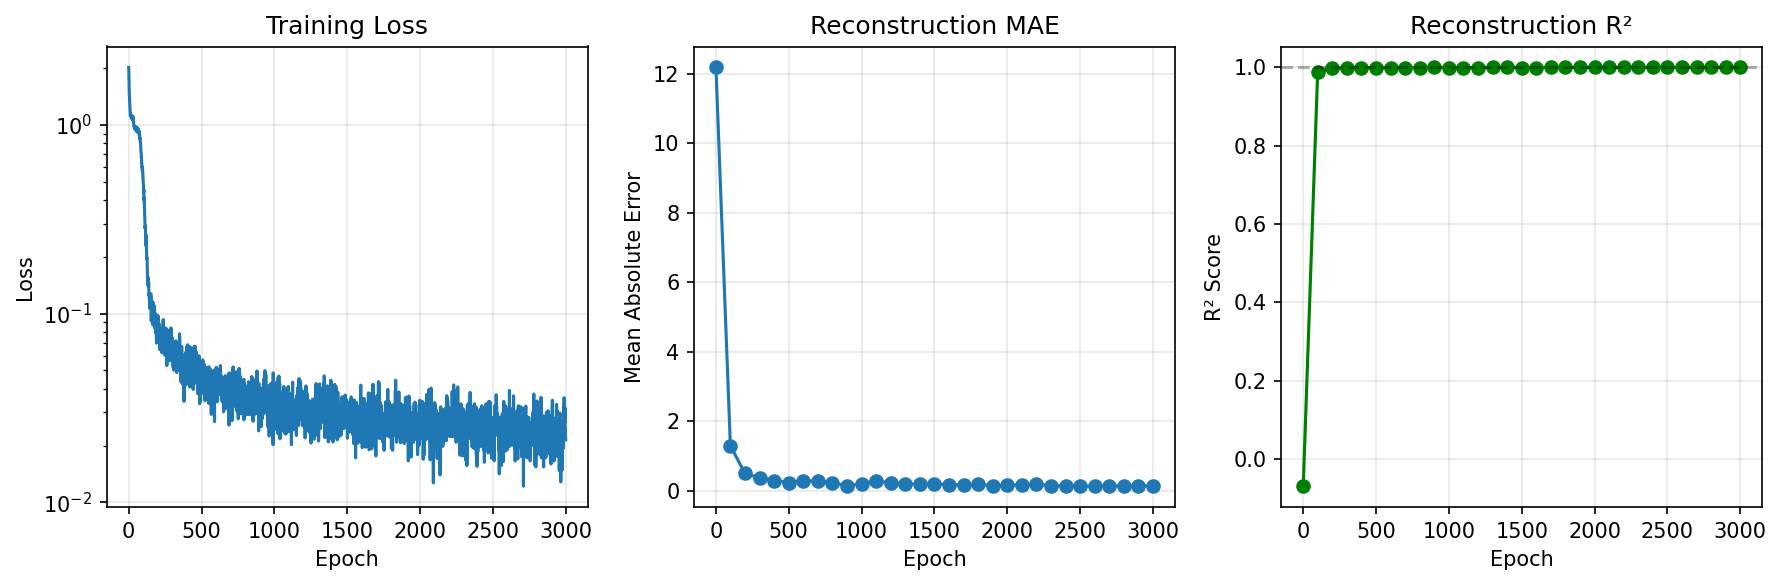

Final Loss: 0.021452
Final MAE:  0.151703
Final R²:   0.999847


In [16]:
# Plot learning curves
fm.plot_learning_curves()

In [17]:
# Generate samples conditioned on X2 = 35.5, P100 = 400, h(x) = 0
target_X2 = TARGET_X2_MIN      # 35.5
target_P100 = TARGET_P100_MAX  # 400.0
target_conditions = np.array([target_X2, target_P100] + [0.0]*12, dtype=np.float32)

print(f"Conditioning on 14-dimensional target:")
print(f"  X2 = {target_X2} (target lower bound - SET directly)")
print(f"  P100 = {target_P100} (target upper bound - SET directly)")
print(f"  h(x) = 0 (equality constraint satisfaction)")
print(f"\nFM generates 14 variables, X2 and P100 are SET directly (same as GMM)")

n_fm_samples = 5000
fm_samples_14 = fm.sample(c_values=[target_conditions], n_samples=n_fm_samples, n_steps=200)

# Reconstruct full 16-variable solution (same approach as GMM!)
remaining_cols = [i for i in range(16) if i not in [5, 11]]
fm_samples = np.zeros((n_fm_samples, 16))
fm_samples[:, remaining_cols] = fm_samples_14
fm_samples[:, 5] = target_X2    # Set X2 directly (not generated)
fm_samples[:, 11] = target_P100  # Set P100 directly (not generated)

# Clip to physical bounds
fm_samples = np.clip(fm_samples, lb, ub)

print(f"\nGenerated {n_fm_samples} samples from Flow Matching")
print(f"  X2 fixed at: {target_X2} (SET directly, not generated)")
print(f"  P100 fixed at: {target_P100} (SET directly, not generated)")

Conditioning on 14-dimensional target:
  X2 = 35.5 (target lower bound - SET directly)
  P100 = 400.0 (target upper bound - SET directly)
  h(x) = 0 (equality constraint satisfaction)

FM generates 14 variables, X2 and P100 are SET directly (same as GMM)



Generated 5000 samples from Flow Matching
  X2 fixed at: 35.5 (SET directly, not generated)
  P100 fixed at: 400.0 (SET directly, not generated)


In [18]:
# Evaluate Flow Matching samples
fm_objectives = np.array([objective(x) for x in fm_samples])
fm_violations = np.array([max_constraint_violation(x) for x in fm_samples])

# Check X2 and P100 values
fm_X2 = fm_samples[:, 5]
fm_P100 = fm_samples[:, 11]

print("Flow Matching Sample Statistics (conditioned on h(x) = 0):")
print(f"  Objective: mean={fm_objectives.mean():.2f}, min={fm_objectives.min():.2f}, max={fm_objectives.max():.2f}")
print(f"  Constraint violation: mean={fm_violations.mean():.4e}, min={fm_violations.min():.4e}")
print(f"  X2 range: [{fm_X2.min():.2f}, {fm_X2.max():.2f}] (target: >= {TARGET_X2_MIN})")
print(f"  P100 range: [{fm_P100.min():.2f}, {fm_P100.max():.2f}] (target: <= {TARGET_P100_MAX})")
print(f"  Samples with violation < 0.1: {(fm_violations < 0.1).sum()}")
print(f"  Samples with violation < 0.01: {(fm_violations < 0.01).sum()}")

Flow Matching Sample Statistics (conditioned on h(x) = 0):
  Objective: mean=-590.07, min=-643.33, max=-547.36
  Constraint violation: mean=2.7831e+00, min=6.2255e-02
  X2 range: [35.50, 35.50] (target: >= 35.5)
  P100 range: [400.00, 400.00] (target: <= 400.0)
  Samples with violation < 0.1: 2
  Samples with violation < 0.01: 0


In [19]:
# Select best Flow Matching sample
# Also filter for target inequality constraints: X2 >= 35.5, P100 <= 400
target_feasible_fm = (fm_violations < 0.1) & (fm_X2 >= TARGET_X2_MIN - 0.1) & (fm_P100 <= TARGET_P100_MAX + 1)

if target_feasible_fm.sum() > 0:
    feasible_idx = np.where(target_feasible_fm)[0]
    best_idx = feasible_idx[np.argmin(fm_objectives[target_feasible_fm])]
    print(f"Found {target_feasible_fm.sum()} samples satisfying target constraints")
else:
    # Fall back to just near-feasible
    feasible_fm = fm_violations < 0.1
    if feasible_fm.sum() > 0:
        feasible_idx = np.where(feasible_fm)[0]
        best_idx = feasible_idx[np.argmin(fm_objectives[feasible_fm])]
        print(f"Found {feasible_fm.sum()} near-feasible samples (may not satisfy target X2/P100)")
    else:
        best_idx = np.argmin(fm_violations)
        print("Warning: No near-feasible samples found, using lowest violation")

x_fm_best = fm_samples[best_idx]

print("\nFlow Matching Best Sample (conditioned on h(x) = 0):")
print(f"  Objective: {objective(x_fm_best):.4f} (target: {scipy_cost:.4f})")
print(f"  Max equality constraint violation: {max_constraint_violation(x_fm_best):.4e}")
print(f"\n  Key variables:")
print(f"    X2:   {x_fm_best[5]:.4f} (target: >= {TARGET_X2_MIN})")
print(f"    P100: {x_fm_best[11]:.4f} (target: <= {TARGET_P100_MAX})")
print(f"    Objective gap: {abs(objective(x_fm_best)-scipy_cost)/abs(scipy_cost)*100:.2f}%")

Found 2 samples satisfying target constraints

Flow Matching Best Sample (conditioned on h(x) = 0):
  Objective: -579.5448 (target: -582.2331)
  Max equality constraint violation: 9.8156e-02

  Key variables:
    X2:   35.5000 (target: >= 35.5)
    P100: 400.0000 (target: <= 400.0)
    Objective gap: 0.46%


---

# Final Comparison

In [20]:
# Summary comparison
print("\n" + "=" * 90)
print("FINAL COMPARISON: GMM vs Flow Matching vs Scipy")
print("=" * 90)

print("\n" + "-" * 90)
print(f"GENERATIVE MODEL OUTPUTS (conditioned on X2={TARGET_X2_MIN}, P100={TARGET_P100_MAX}, h(x)=0):")
print("-" * 90)
print(f"{'Method':<20} {'Objective':>15} {'Max Eq Viol':>15} {'Feasible?':>12} {'X2':>10} {'P100':>10}")
print("-" * 85)
print(f"{'GMM Best':<20} {objective(x_gmm_best):>15.4f} {max_constraint_violation(x_gmm_best):>15.4e} {'Yes' if max_constraint_violation(x_gmm_best) < 0.01 else 'No':>12} {x_gmm_best[5]:>10.2f} {x_gmm_best[11]:>10.2f}")
print(f"{'Flow Matching Best':<20} {objective(x_fm_best):>15.4f} {max_constraint_violation(x_fm_best):>15.4e} {'Yes' if max_constraint_violation(x_fm_best) < 0.01 else 'No':>12} {x_fm_best[5]:>10.2f} {x_fm_best[11]:>10.2f}")

print("\n" + "-" * 90)
print("REFERENCE SOLUTIONS:")
print("-" * 90)
print(f"{'Method':<20} {'Objective':>15} {'Max Eq Viol':>15} {'Feasible?':>12} {'X2':>10} {'P100':>10}")
print("-" * 85)
print(f"{'Scipy (optimal)':<20} {scipy_cost:>15.4f} {max_constraint_violation(scipy_solution):>15.4e} {'Yes' if max_constraint_violation(scipy_solution) < 0.01 else 'No':>12} {scipy_solution[5]:>10.2f} {scipy_solution[11]:>10.2f}")
print(f"{'Literature':<20} {objective(x_opt_lit):>15.4f} {max_constraint_violation(x_opt_lit):>15.4e} {'Yes' if max_constraint_violation(x_opt_lit) < 0.01 else 'No':>12} {x_opt_lit[5]:>10.2f} {x_opt_lit[11]:>10.2f}")

print("\n" + "-" * 90)
print("TRAINING DATA STATISTICS (constraint variation approach):")
print("-" * 90)
print(f"Total training samples: {len(X_train)}")
print(f"Objective range in training: [{obj_train.min():.2f}, {obj_train.max():.2f}]")
print(f"X2 range in training: [{X2_train.min():.2f}, {X2_train.max():.2f}]")
print(f"P100 range in training: [{P100_train.min():.2f}, {P100_train.max():.2f}]")

# Check optimality gap
gmm_gap = abs(objective(x_gmm_best) - scipy_cost) / abs(scipy_cost) * 100
fm_gap = abs(objective(x_fm_best) - scipy_cost) / abs(scipy_cost) * 100
print(f"\n" + "-" * 90)
print("OPTIMALITY GAP:")
print("-" * 90)
print(f"GMM gap: {gmm_gap:.2f}%")
print(f"Flow Matching gap: {fm_gap:.2f}%")

print(f"\n" + "-" * 90)
print("APPROACH: Constraint Bound + Residual Conditioning")
print("-" * 90)
print(f"Conditioning dimensions: 14 total")
print(f"  - X2 = {TARGET_X2_MIN} (target constraint bound)")
print(f"  - P100 = {TARGET_P100_MAX} (target constraint bound)")
print(f"  - h(x) = 0 (12 equality constraint residuals)")
print(f"Training data: {len(X_train)} solutions from varying X2_min and P100_max")


FINAL COMPARISON: GMM vs Flow Matching vs Scipy

------------------------------------------------------------------------------------------
GENERATIVE MODEL OUTPUTS (conditioned on X2=35.5, P100=400.0, h(x)=0):
------------------------------------------------------------------------------------------
Method                     Objective     Max Eq Viol    Feasible?         X2       P100
-------------------------------------------------------------------------------------
GMM Best                   -603.3014      7.8025e-02           No      35.50     400.00
Flow Matching Best         -579.5448      9.8156e-02           No      35.50     400.00

------------------------------------------------------------------------------------------
REFERENCE SOLUTIONS:
------------------------------------------------------------------------------------------
Method                     Objective     Max Eq Viol    Feasible?         X2       P100
-------------------------------------------------------

## Key Observations

**Constraint Bound + Residual Conditioning Approach:**

1. **Data generation**: Vary X2_min ∈ [33%, 38%] and P100_max ∈ [260, 400] kPa

2. **Training data**: Each SLSQP solution has X2 = X2_min and P100 = P100_max (active bounds)

3. **Diversity**: Different constraint bounds → different optimal solutions → diverse training data

4. **Conditioning**: 
   - X2 = 35.5: target constraint bound (column 5)
   - P100 = 400: target constraint bound (column 11)  
   - h(x) = 0: equality constraint residuals (columns 16-27)

**Why this approach is defensible:**
- Constraint bounds (X2 ≥ 35.5, P100 ≤ 400) are **part of the problem specification**
- We're not guessing which constraints are active - we're specifying the target configuration
- Training data covers a range of configurations → model learns how solution varies
- At inference, we query for the specific target configuration
- Similar to parameter estimation: condition on known values, generate unknown variables

**Comparison to other approaches:**
- **h(x) = 0 only**: Doesn't specify target X2/P100, relies on post-sampling filtering
- **Slack variables**: Adds redundant dimensions, less direct
- **This approach**: Direct, efficient, clearly specifies the optimization target

---

# Publication Figures

Generate publication-quality figures comparing GMM and Flow Matching approaches.

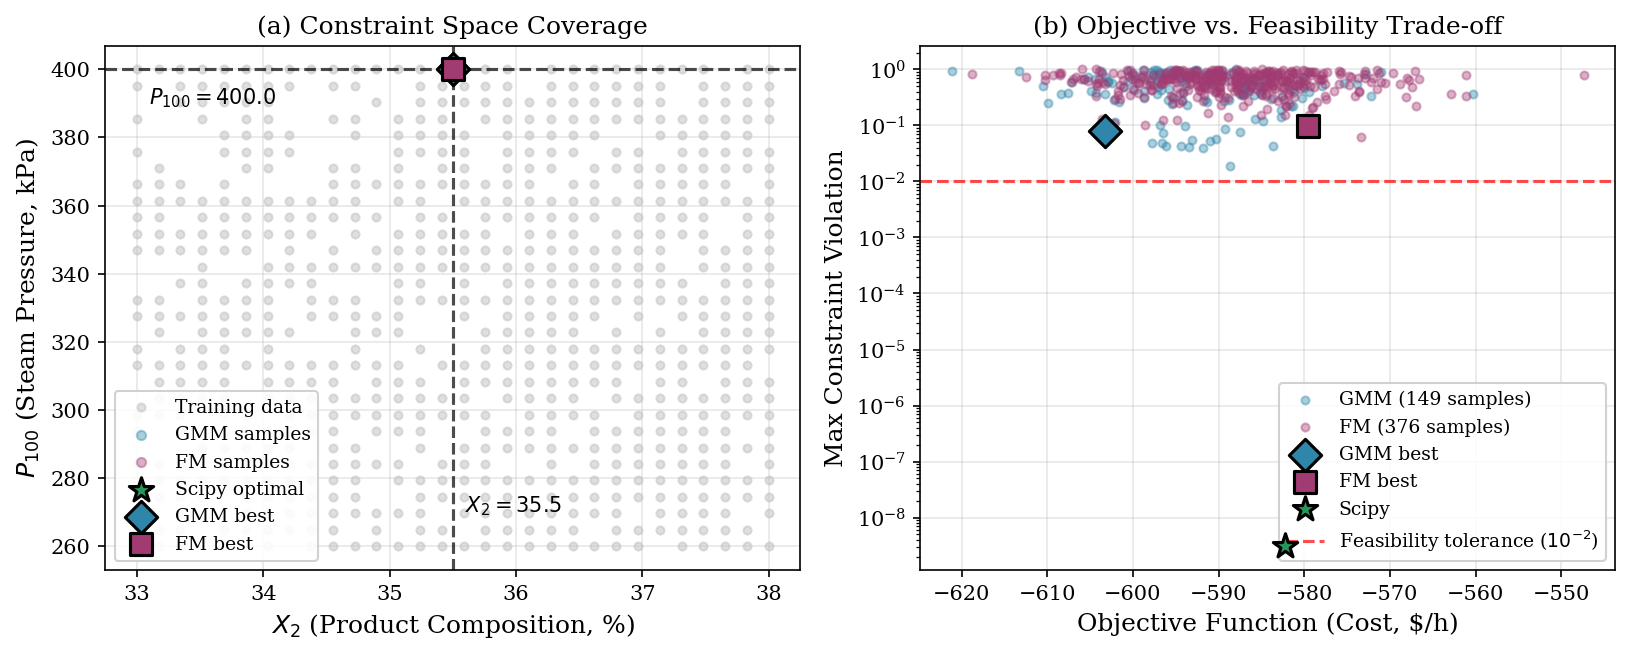

Saved: evaporator_training_coverage.pdf


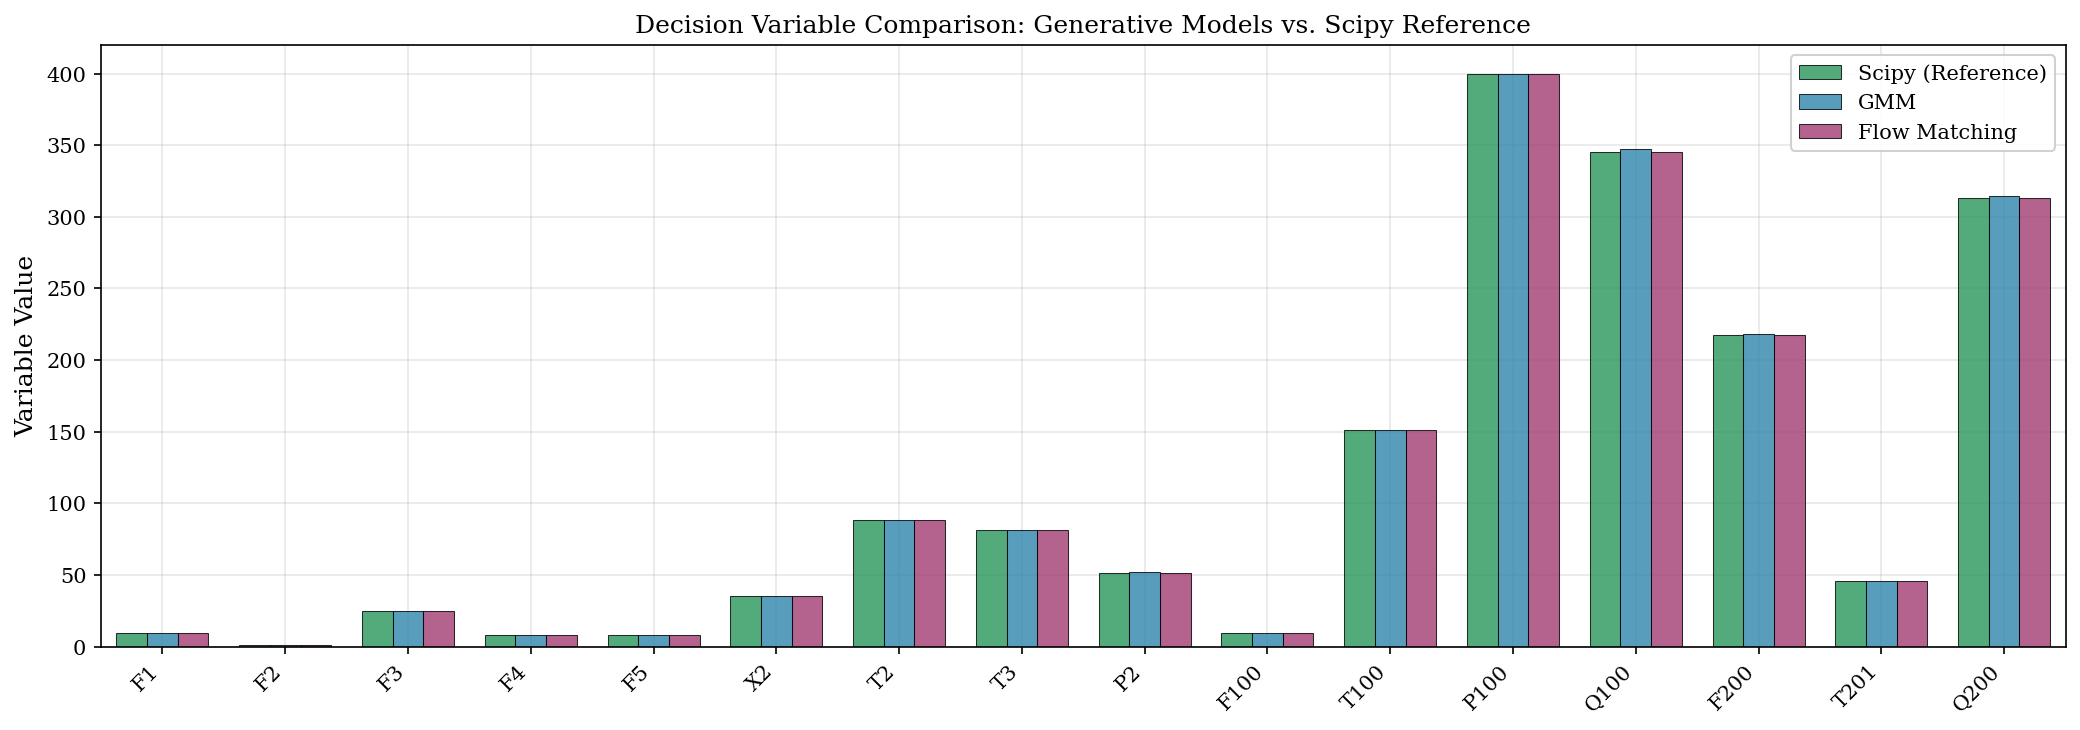

Saved: evaporator_variables_comparison.pdf


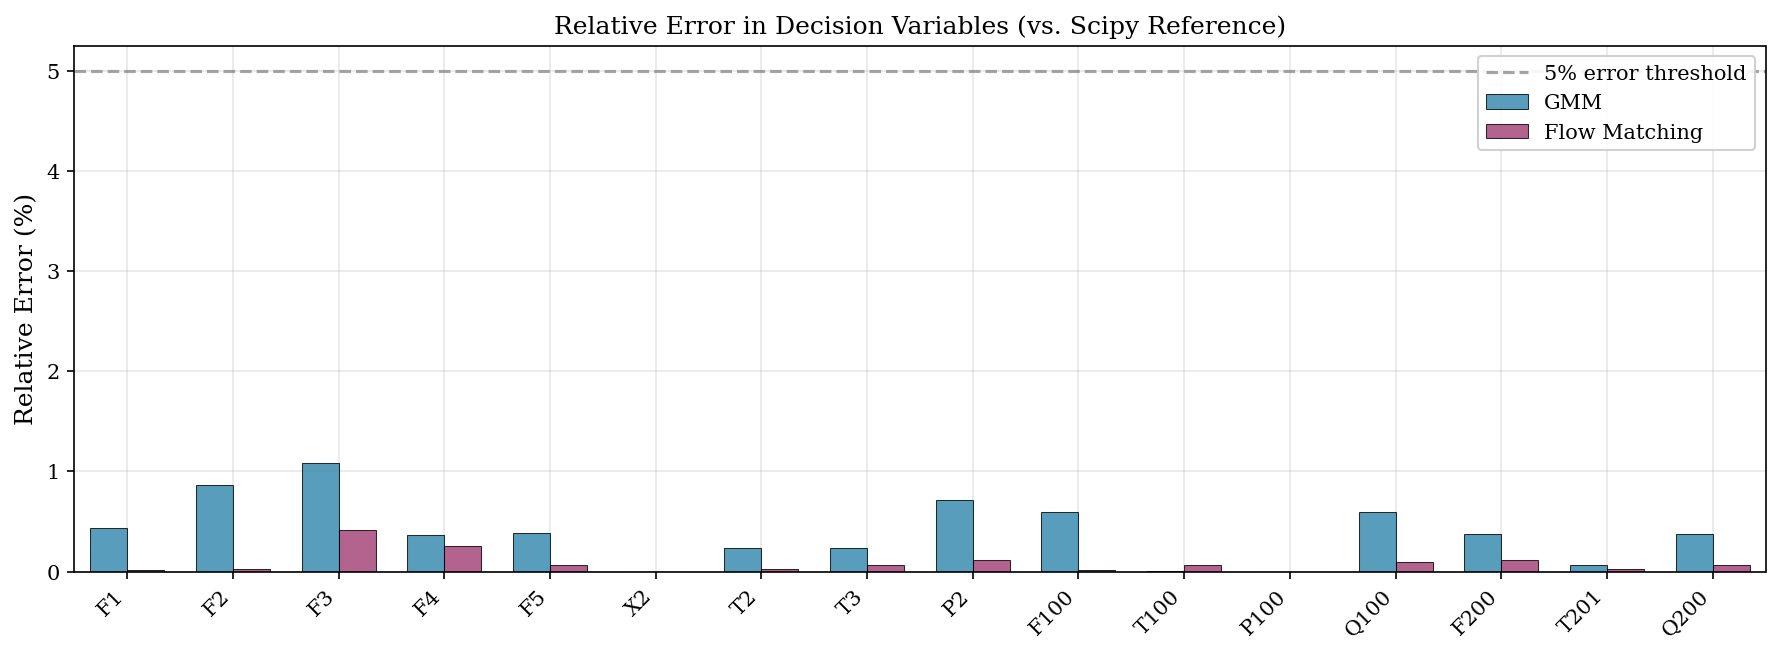

Saved: evaporator_relative_error.pdf


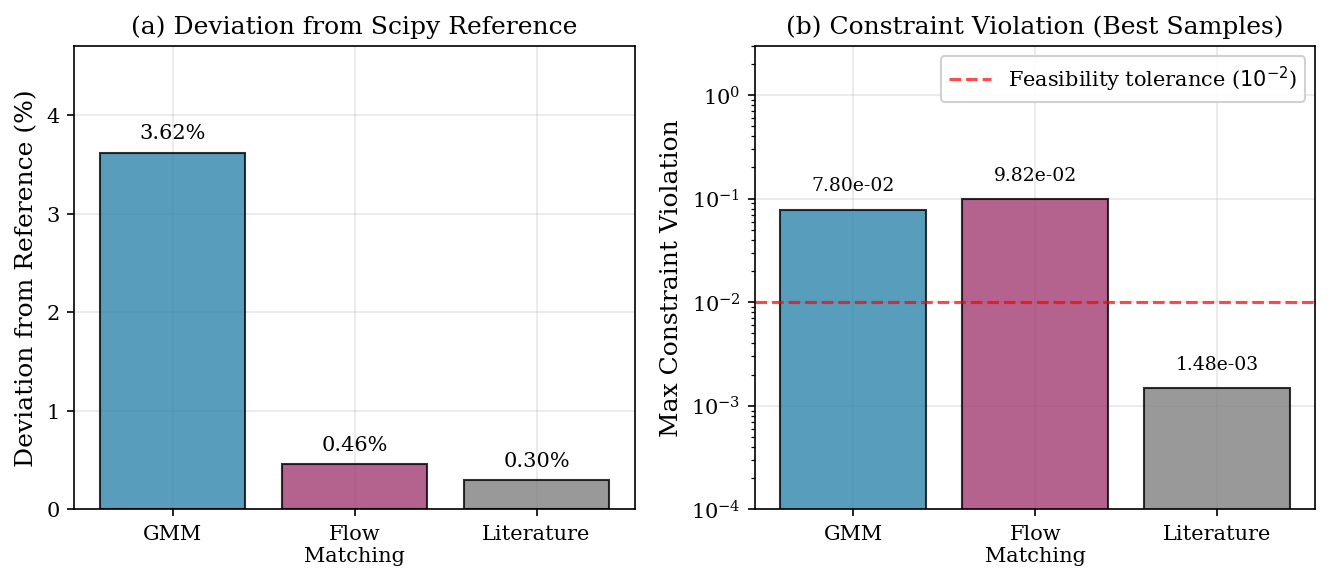

Saved: evaporator_summary_comparison.pdf

PUBLICATION FIGURES SAVED:
1. evaporator_training_coverage.pdf     - Training data & solution space
2. evaporator_variables_comparison.pdf  - Decision variable bar chart
3. evaporator_relative_error.pdf        - Relative error comparison
4. evaporator_summary_comparison.pdf    - Summary metrics (best samples)


In [21]:
# Publication-quality figures
# ============================================================================
# Configure matplotlib for publication
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.axisbelow': True,
})

# Color scheme
colors = {
    'gmm': '#2E86AB',      # Blue
    'fm': '#A23B72',       # Magenta/Purple
    'scipy': '#28965A',    # Green
    'training': '#C0C0C0', # Gray
}

# ============================================================================
# Figure 1: Training Data Coverage & Target Solution
# ============================================================================
fig1, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Panel (a): X2 vs P100 space with samples
ax = axes[0]

# Training data
ax.scatter(X2_train, P100_train, c=colors['training'], s=15, alpha=0.5, 
           label='Training data', zorder=1)

# GMM samples (subset for clarity)
n_plot = min(500, len(gmm_samples))
idx = np.random.choice(len(gmm_samples), n_plot, replace=False)
ax.scatter(gmm_samples[idx, 5], gmm_samples[idx, 11], c=colors['gmm'], 
           s=20, alpha=0.4, label='GMM samples', zorder=2)

# FM samples (subset)
idx = np.random.choice(len(fm_samples), n_plot, replace=False)
ax.scatter(fm_samples[idx, 5], fm_samples[idx, 11], c=colors['fm'],
           s=20, alpha=0.4, label='FM samples', zorder=2)

# Reference solutions
ax.scatter([scipy_solution[5]], [scipy_solution[11]], c=colors['scipy'], s=150,
           marker='*', edgecolors='black', linewidths=1.5, zorder=10, label='Scipy optimal')
ax.scatter([x_gmm_best[5]], [x_gmm_best[11]], c=colors['gmm'], s=120,
           marker='D', edgecolors='black', linewidths=1.5, zorder=10, label='GMM best')
ax.scatter([x_fm_best[5]], [x_fm_best[11]], c=colors['fm'], s=120,
           marker='s', edgecolors='black', linewidths=1.5, zorder=10, label='FM best')

# Target constraint bounds
ax.axvline(TARGET_X2_MIN, color='black', ls='--', lw=1.5, alpha=0.7)
ax.axhline(TARGET_P100_MAX, color='black', ls='--', lw=1.5, alpha=0.7)
ax.text(TARGET_X2_MIN + 0.1, 270, f'$X_2 = {TARGET_X2_MIN}$', fontsize=10)
ax.text(33.1, TARGET_P100_MAX - 10, f'$P_{{100}} = {TARGET_P100_MAX}$', fontsize=10)

ax.set_xlabel('$X_2$ (Product Composition, %)')
ax.set_ylabel('$P_{100}$ (Steam Pressure, kPa)')
ax.set_title('(a) Constraint Space Coverage')
ax.legend(loc='lower left', framealpha=0.9, fontsize=9)

# Panel (b): Objective vs Constraint Violation scatter
ax = axes[1]

# Filter for visualization
viol_thresh = 1.0  # Only show samples with reasonable violation

gmm_mask = gmm_violations < viol_thresh
fm_mask = fm_violations < viol_thresh

ax.scatter(gmm_objectives[gmm_mask], gmm_violations[gmm_mask], 
           c=colors['gmm'], s=15, alpha=0.4, label=f'GMM ({gmm_mask.sum()} samples)')
ax.scatter(fm_objectives[fm_mask], fm_violations[fm_mask],
           c=colors['fm'], s=15, alpha=0.4, label=f'FM ({fm_mask.sum()} samples)')

# Best solutions
ax.scatter([objective(x_gmm_best)], [max_constraint_violation(x_gmm_best)],
           c=colors['gmm'], s=120, marker='D', edgecolors='black', linewidths=1.5,
           zorder=10, label='GMM best')
ax.scatter([objective(x_fm_best)], [max_constraint_violation(x_fm_best)],
           c=colors['fm'], s=120, marker='s', edgecolors='black', linewidths=1.5,
           zorder=10, label='FM best')
ax.scatter([scipy_cost], [max_constraint_violation(scipy_solution)],
           c=colors['scipy'], s=150, marker='*', edgecolors='black', linewidths=1.5,
           zorder=10, label='Scipy')

# Feasibility threshold: the same 1e-2 tolerance used to accept a point
# as feasible everywhere else in this notebook.
ax.axhline(0.01, color='red', ls='--', lw=1.5, alpha=0.7,
           label='Feasibility tolerance ($10^{-2}$)')

ax.set_xlabel('Objective Function (Cost, $/h)')
ax.set_ylabel('Max Constraint Violation')
ax.set_title('(b) Objective vs. Feasibility Trade-off')
ax.legend(loc='lower right', framealpha=0.9, fontsize=9)
ax.set_yscale('log')

plt.tight_layout()
plt.savefig('evaporator_training_coverage.pdf', format='pdf')
plt.savefig('evaporator_training_coverage.png', dpi=300)
plt.show()

print("Saved: evaporator_training_coverage.pdf")

# ============================================================================
# Figure 2: Decision Variable Comparison (Bar Chart)
# ============================================================================
fig2, ax = plt.subplots(figsize=(14, 5))

# Select subset of interesting variables for readability
# Group: flows, compositions/temps, pressures/duties
var_indices = list(range(16))
n_vars = len(var_indices)
x_pos = np.arange(n_vars)
width = 0.25

# Get values for each method
gmm_vals = x_gmm_best[var_indices]
fm_vals = x_fm_best[var_indices]
scipy_vals = scipy_solution[var_indices]

# Create grouped bar chart
bars_scipy = ax.bar(x_pos - width, scipy_vals, width, label='Scipy (Reference)', 
                    color=colors['scipy'], alpha=0.8, edgecolor='black', linewidth=0.5)
bars_gmm = ax.bar(x_pos, gmm_vals, width, label='GMM', 
                  color=colors['gmm'], alpha=0.8, edgecolor='black', linewidth=0.5)
bars_fm = ax.bar(x_pos + width, fm_vals, width, label='Flow Matching',
                 color=colors['fm'], alpha=0.8, edgecolor='black', linewidth=0.5)

ax.set_xticks(x_pos)
ax.set_xticklabels(NAMES, rotation=45, ha='right')
ax.set_ylabel('Variable Value')
ax.set_title('Decision Variable Comparison: Generative Models vs. Scipy Reference')
ax.legend(loc='upper right', framealpha=0.9)
ax.set_xlim(-0.5, n_vars - 0.5)

# Add subtle grid
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('evaporator_variables_comparison.pdf', format='pdf')
plt.savefig('evaporator_variables_comparison.png', dpi=300)
plt.show()

print("Saved: evaporator_variables_comparison.pdf")

# ============================================================================
# Figure 3: Relative Error in Decision Variables
# ============================================================================
fig3, ax = plt.subplots(figsize=(12, 4.5))

# Compute relative errors (percentage)
gmm_rel_err = np.abs(gmm_vals - scipy_vals) / (np.abs(scipy_vals) + 1e-10) * 100
fm_rel_err = np.abs(fm_vals - scipy_vals) / (np.abs(scipy_vals) + 1e-10) * 100

x_pos = np.arange(n_vars)
width = 0.35

bars_gmm = ax.bar(x_pos - width/2, gmm_rel_err, width, label='GMM',
                  color=colors['gmm'], alpha=0.8, edgecolor='black', linewidth=0.5)
bars_fm = ax.bar(x_pos + width/2, fm_rel_err, width, label='Flow Matching',
                 color=colors['fm'], alpha=0.8, edgecolor='black', linewidth=0.5)

# Reference line for 5% error
ax.axhline(5, color='gray', ls='--', lw=1.5, alpha=0.7, label='5% error threshold')

ax.set_xticks(x_pos)
ax.set_xticklabels(NAMES, rotation=45, ha='right')
ax.set_ylabel('Relative Error (%)')
ax.set_title('Relative Error in Decision Variables (vs. Scipy Reference)')
ax.legend(loc='upper right', framealpha=0.9)
ax.set_xlim(-0.5, n_vars - 0.5)

# Cap y-axis for readability if there are outliers
if max(gmm_rel_err.max(), fm_rel_err.max()) > 50:
    ax.set_ylim(0, min(50, max(gmm_rel_err.max(), fm_rel_err.max()) * 1.1))

plt.tight_layout()
plt.savefig('evaporator_relative_error.pdf', format='pdf')
plt.savefig('evaporator_relative_error.png', dpi=300)
plt.show()

print("Saved: evaporator_relative_error.pdf")

# ============================================================================
# Figure 4: Summary Bar Chart (Deviation & Feasibility for BEST samples)
# ============================================================================
fig4, axes = plt.subplots(1, 2, figsize=(9, 4))

# Panel (a): Deviation from the scipy reference objective
ax = axes[0]
methods = ['GMM', 'Flow\nMatching', 'Literature']
deviations = [
    abs(objective(x_gmm_best) - scipy_cost) / abs(scipy_cost) * 100,
    abs(objective(x_fm_best) - scipy_cost) / abs(scipy_cost) * 100,
    abs(objective(x_opt_lit) - scipy_cost) / abs(scipy_cost) * 100
]
bar_colors = [colors['gmm'], colors['fm'], 'gray']

bars = ax.bar(methods, deviations, color=bar_colors, alpha=0.8, edgecolor='black', linewidth=1)
ax.set_ylabel('Deviation from Reference (%)')
ax.set_title('(a) Deviation from Scipy Reference')
ax.set_ylim(0, max(deviations) * 1.3)

# Add value labels on bars
for bar, dev in zip(bars, deviations):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{dev:.2f}%', ha='center', va='bottom', fontsize=10)

# Panel (b): Constraint violation for BEST samples
ax = axes[1]
violations = [
    max_constraint_violation(x_gmm_best),
    max_constraint_violation(x_fm_best),
    max_constraint_violation(x_opt_lit)
]

bars = ax.bar(methods, violations, color=bar_colors, alpha=0.8, edgecolor='black', linewidth=1)
ax.axhline(0.01, color='red', ls='--', lw=1.5, alpha=0.7,
           label='Feasibility tolerance ($10^{-2}$)')
ax.set_ylabel('Max Constraint Violation')
ax.set_title('(b) Constraint Violation (Best Samples)')
ax.set_yscale('log')
ax.set_ylim(1e-4, 3)
ax.legend(loc='upper right', framealpha=0.9)

# Add value labels
for bar, viol in zip(bars, violations):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.4,
            f'{viol:.2e}', ha='center', va='bottom', fontsize=9, rotation=0)

plt.tight_layout()
plt.savefig('evaporator_summary_comparison.pdf', format='pdf')
plt.savefig('evaporator_summary_comparison.png', dpi=300)
plt.show()

print("Saved: evaporator_summary_comparison.pdf")

# ============================================================================
# Print summary of all saved figures
# ============================================================================
print("\n" + "=" * 70)
print("PUBLICATION FIGURES SAVED:")
print("=" * 70)
print("1. evaporator_training_coverage.pdf     - Training data & solution space")
print("2. evaporator_variables_comparison.pdf  - Decision variable bar chart")
print("3. evaporator_relative_error.pdf        - Relative error comparison")
print("4. evaporator_summary_comparison.pdf    - Summary metrics (best samples)")
print("=" * 70)

In [22]:
# Relative-error figures quoted in the manuscript text
i_gmm, i_fm = int(np.argmax(gmm_rel_err)), int(np.argmax(fm_rel_err))
print(f"Max relative error, GMM: {gmm_rel_err[i_gmm]:.2f}%  ({NAMES[i_gmm]})")
print(f"Max relative error, FM : {fm_rel_err[i_fm]:.2f}%  ({NAMES[i_fm]})")
print()
print(f"{'var':<8}{'GMM %':>9}{'FM %':>9}")
for k in np.argsort(-np.maximum(gmm_rel_err, fm_rel_err))[:6]:
    print(f"{NAMES[k]:<8}{gmm_rel_err[k]:>9.3f}{fm_rel_err[k]:>9.3f}")


Max relative error, GMM: 1.09%  (F3)
Max relative error, FM : 0.42%  (F3)

var         GMM %     FM %
F3          1.089    0.420
F2          0.867    0.026
P2          0.718    0.113
F100        0.594    0.019
Q100        0.592    0.096
F1          0.433    0.011
